In [67]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from scipy.integrate import dblquad, tplquad, quad
from scipy.stats import multivariate_normal, norm
#import numpyro
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [73]:
def pyro_model1_(data, parameter_len, epsilon, prior_sigma):
    prior_parameter = pyro.sample("prior_parameter", dist.MultivariateNormal(torch.zeros(parameter_len), torch.eye(parameter_len)*(prior_sigma**2)))
    mean = torch.tensor([prior_parameter[0] - torch.max(prior_parameter), prior_parameter[1]]).float()
    with pyro.plate("data_plate"):
        pyro.sample("obs", dist.MultivariateNormal(mean, (epsilon**2)*torch.eye(len(data))), obs=data)

def pyro_model2_(data, parameter_len, epsilon, prior_sigma):
    prior_parameter = pyro.sample("prior_parameter", dist.MultivariateNormal(torch.zeros(parameter_len), torch.eye(parameter_len)*(prior_sigma**2)))
    mean = torch.tensor([prior_parameter[0] - torch.maximum(prior_parameter[1], prior_parameter[2]), prior_parameter[1]]).float()
    with pyro.plate("data_plate"):
        pyro.sample("obs", dist.MultivariateNormal(mean, (epsilon**2)*torch.eye(len(data))), obs=data)  


def run_HMC(data, model, parameter_len, epsilon, prior_sigma, stepsize, num_samples, initial_params, warmup_steps):

    pyro.clear_param_store()
    pyro_model = lambda data: model(data=data, parameter_len=parameter_len, epsilon=epsilon, prior_sigma=prior_sigma)
    pyro_kernel =  pyro.infer.mcmc.NUTS(model=pyro_model, step_size=stepsize)
    pyro_mcmc = pyro.infer.mcmc.MCMC(kernel=pyro_kernel, num_samples=num_samples, initial_params={'prior_parameter': initial_params}, warmup_steps=warmup_steps)
    pyro_mcmc.run(data)
    samples = pyro_mcmc.get_samples()["prior_parameter"]
                    
    return samples



In [90]:
def ABC_prob_model1(epsilon, prior_sigma, data):
    def fn_(y, x, epsilon, prior_sigma):
        #y is theta2, x is theta1
        lh = multivariate_normal.pdf(data.numpy(), mean=np.array([x - np.maximum(x,y), y]), cov=epsilon**2)
        pr = multivariate_normal.pdf(np.array([x,y]), mean=np.array([0.,0.]), cov=prior_sigma**2)
        return lh*pr
    fn = lambda y, x: fn_(y, x, epsilon=epsilon, prior_sigma=prior_sigma)
    numerator = dblquad(fn, -np.inf, np.inf, lambda x:x, np.inf)[0]
    denominator = dblquad(fn, -np.inf, np.inf, -np.inf, np.inf)[0]
    return numerator / denominator, 1.


def ABC_prob_model2(epsilon, prior_sigma, data):
    
    
    data = data.numpy()
    B1 = np.array([[1,-1,0],[0,1,0]])
    B2 = np.array([[1,0,-1],[0,1,0]])
    Gamma1inv = prior_sigma**2 * B1 @ B1.T + epsilon**2 * np.eye(2)
    Gamma2inv = prior_sigma**2 * B2 @ B2.T + epsilon**2 * np.eye(2)
    Gamma1 = np.linalg.inv(Gamma1inv)
    Gamma2 = np.linalg.inv(Gamma2inv)
    mu1 = prior_sigma**2 * B1.T @ Gamma1 @ data.reshape((-1,1))
    mu2 = prior_sigma**2 * B2.T @ Gamma2 @ data.reshape((-1,1))
    Sigma1 = prior_sigma**2 * np.eye(3) - prior_sigma**4 * B1.T @ Gamma1 @ B1
    Sigma2 = prior_sigma**2 * np.eye(3) - prior_sigma**4 * B2.T @ Gamma2 @ B2
    
    v1 = np.array([0.,-1.,1.])
    v2 = np.array([0.,1.,-1.])
    I1 =  norm.cdf(0., loc=mu1[2]-mu1[1], scale=np.sqrt(v1.reshape((1,-1)) @ Sigma1 @ v1.reshape((-1,1))))
    I2 =  norm.cdf(0., loc=mu2[1]-mu2[2], scale=np.sqrt(v2.reshape((1,-1)) @ Sigma2 @ v2.reshape((-1,1))))

    Rprior1 = multivariate_normal.pdf(data, mean=np.array([0.,0.]), cov=Gamma1inv)
    Rprior2 = multivariate_normal.pdf(data, mean=np.array([0.,0.]), cov=Gamma2inv)
    
    star_fn = lambda x: multivariate_normal.pdf(np.array([data[0] + np.maximum(data[1],x), data[1],x]), mean=np.array([0,0,0]), cov=prior_sigma**2 * np.eye(3))
    num_star = quad(star_fn, a=-np.inf, b=data[1])[0]
    denom_star = quad(star_fn, a=-np.inf, b=np.inf)[0]

    return (Rprior1 * I1 / (Rprior1 * I1 + Rprior2 * I2)).flatten(), num_star/denom_star
    
    
#     def fn_(z, y, x, epsilon, prior_sigma):
#         #z is theta3, y is theta2, x is theta1
#         lh = multivariate_normal.pdf(data.numpy(), mean=np.array([x - np.maximum(y,z), y]), cov=epsilon**2)
#         pr = multivariate_normal.pdf(np.array([x,y,z]), mean=np.array([0.,0.,0.]), cov=prior_sigma**2)
#         return lh*pr
#     fn = lambda z, y, x: fn_(z, y, x, epsilon=epsilon, prior_sigma=prior_sigma)
#     numerator = tplquad(fn, -np.inf, np.inf, -np.inf, np.inf, lambda x,y: y, np.inf)[0]
#     denominator = tplquad(fn, -np.inf, np.inf, -np.inf, np.inf, -np.inf, np.inf)[0]

In [76]:
def GR(x):
    return numpyro.diagnostics.gelman_rubin(x)

def ABC_error(p_eps, p_true):
    return (p_true-p_eps)**2

def MCMC_error(p_eps, weights, particles, g_idx=1, l_idx=0):
    return (p_eps - np.sum([weights[i] for i in range(len(weights)) if particles[i][g_idx] > particles[i][l_idx]]))**2

def Overall_error(p_true, weights, particles, g_idx=1, l_idx=0):
    return (p_true - np.sum([weights[i] for i in range(len(weights)) if particles[i][g_idx] > particles[i][l_idx]]))**2


In [95]:
def SMC_weights1(new_eps, old_eps, data, theta):
    return -(1/(2*new_eps**2) - 1/(2*old_eps**2))*((data.numpy()[0]-(theta[0]-np.max(theta)))**2+(data.numpy()[1]-theta[1])**2)

def SMC_weights2(new_eps, old_eps, data, theta):
    return -(1/(2*new_eps**2) - 1/(2*old_eps**2))*((data.numpy()[0]-(theta[0]-np.maximum(theta[1],theta[2])))**2+(data.numpy()[1]-theta[1])**2)

In [102]:
#main parameter
###Model 1
# data = torch.tensor([-1.,-1.])
# parameter_len = 2
# prior_sigma = 1.
# model = pyro_model1_
# ABC_prob_model = ABC_prob_model1
# g_idx = 1
# l_idx = 0
# initial_params = torch.tensor([-2.,-1.])
# SMC_weights_fn = SMC_weights1


###Model 2
data = torch.tensor([-0.5,0.5])
parameter_len = 3
prior_sigma = 1.
model = pyro_model2_
ABC_prob_model = ABC_prob_model2
g_idx = 1
l_idx = 2
initial_params = torch.tensor([0.,0.5,0.])
SMC_weights_fn = SMC_weights2


# ####amendable parameter

initial_eps = 10.
num_particles = 200
eps_range = [0.1, 0.3, 0.5, 0.7, 0.9]
#eps_range = [0.1,0.3,0.5,0.7,0.9]

initial_warmup_steps = 1000
resample_rate = 100
initial_num_samples = num_particles*resample_rate
stepsize = 0.1

warmup_steps = 20
num_samples = 100


##testing parameters
num_particles = 2
eps_range = [0.1,0.3]
initial_warmup_steps = 1
resample_rate = 1
initial_num_samples = num_particles*resample_rate
stepsize = 0.1

warmup_steps = 2
num_samples = 5



p0_samples = run_HMC(data=data,
        model=model,
        parameter_len=parameter_len, 
        epsilon=initial_eps, 
        prior_sigma=prior_sigma, 
        stepsize=stepsize, 
        num_samples=initial_num_samples, 
        initial_params=initial_params, 
        warmup_steps=initial_warmup_steps).numpy()[::resample_rate]



#SMC
all_particles_full = []
all_particles = []
all_weights = []
#all_gr = []
all_abcerror = []
all_mcmcerror = []
all_overallerror = []

for eps in eps_range:
    logweights = np.zeros(num_particles)
    particles = np.zeros([num_particles,parameter_len])
    particles_full = np.zeros([num_particles, num_samples, parameter_len])
    for n in range(num_particles):
        print("Working on eps {}, particle, {}...".format(eps, n))
        #smc
        sample = p0_samples[n]
        wn = SMC_weights_fn(new_eps=eps, old_eps=initial_eps, data=data, theta=sample)
        logweights[n] = wn
        
        #MCMC
        pn = run_HMC(data=data,
                model=model,
                parameter_len=parameter_len, 
                epsilon=eps, 
                prior_sigma=prior_sigma, 
                stepsize=stepsize, 
                num_samples=num_samples, 
                initial_params=torch.tensor(p0_samples[n]), 
                warmup_steps=warmup_steps).numpy()
        particles[n] = pn[-1]
        particles_full[n] = pn
    
    weights = np.exp(logweights - logsumexp(logweights))
    
    all_particles_full.append(particles_full)
    all_particles.append(particles)
    all_weights.append(weights)
    
    
    #Metrics
    #gr = np.array([GR(np.array(particles_full)[:,:,0]),GR(np.array(particles_full)[:,:,1])])
    p_eps, p_true = ABC_prob_model(eps, prior_sigma, data)
    abcerror = ABC_error(p_eps, p_true)
    mcmcerror = MCMC_error(p_eps, weights, particles, g_idx, l_idx)
    overallerror = Overall_error(p_true, weights, particles, g_idx, l_idx)
    
    #all_gr.append(gr)
    all_abcerror.append(abcerror)
    all_mcmcerror.append(mcmcerror)
    all_overallerror.append(overallerror)
    
#     np.savez("../abcerrorresults/eps{}.npz".format(str(eps).replace(".","-")),
#         particles_full=particles_full, 
#              particles=particles, 
#              weights=weights,
#             #gr=gr,
#             abcerror=abcerror,
#             mcmcerror=mcmcerror,
#             overallerror=overallerror)
    

Sample: 100%|█████████████████████████████████████████████| 3/3 [00:00, 71.41it/s, step size=8.00e-01, acc. prob=0.784]


Working on eps 0.1, particle, 0...


Sample: 100%|████████████████████████████████████████████| 7/7 [00:00, 126.08it/s, step size=2.26e+00, acc. prob=0.067]


Working on eps 0.1, particle, 1...


Sample: 100%|████████████████████████████████████████████| 7/7 [00:00, 150.47it/s, step size=2.42e+00, acc. prob=0.000]


Working on eps 0.3, particle, 0...


Sample: 100%|█████████████████████████████████████████████| 7/7 [00:00, 27.23it/s, step size=1.79e-01, acc. prob=0.599]


Working on eps 0.3, particle, 1...


Sample: 100%|█████████████████████████████████████████████| 7/7 [00:00, 25.59it/s, step size=1.58e-01, acc. prob=0.473]


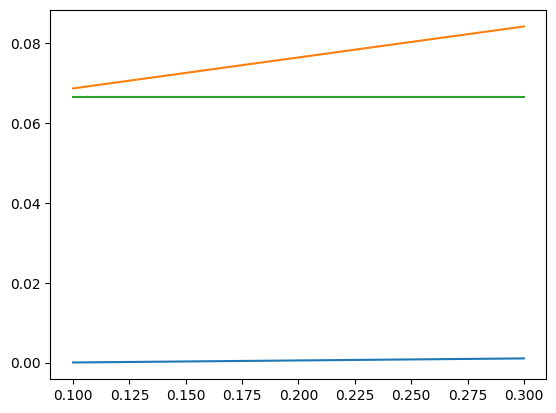

In [103]:
plt.plot(eps_range, all_abcerror)
plt.plot(eps_range, all_mcmcerror)
plt.plot(eps_range, all_overallerror)

In [104]:
file001 = np.load("../abcerrorresults/eps{}.npz".format("0-01"))
file001["particles"]

FileNotFoundError: [Errno 2] No such file or directory: '../abcerrorresults/eps0-01.npz'

In [41]:
all_particles

[array([[-1.84093082, -0.91824836],
        [-2.13671398, -1.21110201],
        [-1.96859145, -0.98211354],
        [-1.77674723, -0.89536166],
        [-1.80777061, -0.76734138],
        [-2.05834723, -1.0585283 ],
        [-1.88713276, -0.77028644],
        [-1.89415359, -0.81031948],
        [-2.08666754, -1.09898448],
        [-1.97702217, -0.85553253],
        [-2.05210471, -0.94825786],
        [-1.7861408 , -0.98039711],
        [-1.98952734, -1.06049943],
        [-1.92537355, -0.91200262],
        [-2.11891174, -0.95797831],
        [-2.04184556, -1.10085464],
        [-1.80685997, -0.87220925],
        [-1.81527662, -0.92501658],
        [-1.90995228, -0.91774172],
        [-1.83050907, -0.88775778],
        [-1.93175197, -0.90116102],
        [-1.83347011, -0.82260597],
        [-2.03685951, -0.95399553],
        [-2.09553719, -0.9379254 ],
        [-2.01205778, -0.95328236],
        [-2.01522231, -0.92719537],
        [-2.08985949, -1.03498363],
        [-1.8308928 , -0.853

In [35]:
all_abcerror

[5.844511461343226e-17,
 0.002658089242543607,
 0.20228033668850504,
 0.322041168098648,
 0.34490573223364823]

In [34]:
all_mcmcerror = [MCMC_error( ABC_prob(eps, prior_sigma, data), ) for i in all_abcerror]

In [ ]:
all_ab